El presente notebook muestra los resultados de la implementación de un modelo de redes neruonales convolucionales simple, con un total de 6 capas.

Importación de librerías

In [1]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split  # Importa función para dividir datos en entrenamiento y prueba
from tensorflow.keras.models import Model, Sequential # Importa la clase Model de Keras
from tensorflow.keras.layers import Conv2D, Input, BatchNormalization,MaxPooling2D, Flatten, Dense, Dropout, UpSampling2D  # Importa capas de Keras para construir el modelo
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint  # Importa el callback
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
import matplotlib.pyplot as plt

2025-10-27 10:29:56.641169: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-27 10:29:56.648132: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-27 10:29:57.065198: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-27 10:29:58.137571: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

Funciones

In [2]:
# Función de redimensionado
def resize_npy_images(d_original, d_reducida, new_size):  # Define función para redimensionar imágenes .npy
    if not os.path.exists(d_reducida):  # Si el directorio reducido no existe
        os.makedirs(d_reducida)  # Lo crea
    for filename in os.listdir(d_original):  # Recorre los archivos en el directorio original
        if filename.lower().endswith('.npy'):  # Si el archivo es .npy
            img_path = os.path.join(d_original, filename)  # Construye la ruta completa del archivo
            img_array = np.load(img_path)  # Carga el array de la imagen
             # Redimensionar usando PIL
            img_resized = np.array(Image.fromarray(img_array).resize(new_size, Image.LANCZOS))
            np.save(os.path.join(d_reducida, filename), img_resized)


In [3]:
#Función para visualizar imagenes

def mostrar_resultados(X, y, y_pred, n=5, cmap='viridis',
                       titulo_general="Comparación de Resultados",
                       xlabel="Eje X (pixeles)", ylabel="Eje Y (pixeles)"):
    """
    Muestra comparaciones entre imágenes de entrada, reales y predichas.

    Parámetros:
        X (numpy array): Entradas (ej. [num_samples, h, w, 1]).
        y (numpy array): Valores reales (targets).
        y_pred (numpy array): Predicciones del modelo.
        n (int): Número de ejemplos a mostrar.
        cmap (str): Mapa de color para mostrar las imágenes.
        titulo_general (str): Título general de la figura.
        xlabel (str): Etiqueta para el eje X.
        ylabel (str): Etiqueta para el eje Y.
    """
    # Ajustar n si es mayor al número de ejemplos disponibles
    n = min(n, len(X))

    fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))
    fig.suptitle(titulo_general, fontsize=16, y=1.02)  # título principal arriba

    for i in range(n):
        # Entrada
        axs[i, 0].imshow(X[i, ..., 0], cmap=cmap)
        axs[i, 0].set_title(f'Entrada t={i}')
        axs[i, 0].set_xlabel(xlabel)
        axs[i, 0].set_ylabel(ylabel)

        # Real
        axs[i, 1].imshow(y[i, ..., 0], cmap=cmap)
        axs[i, 1].set_title(f'Real t+1={i+1}')
        axs[i, 1].set_xlabel(xlabel)
        axs[i, 1].set_ylabel(ylabel)

        # Predicción
        axs[i, 2].imshow(y_pred[i, ..., 0], cmap=cmap)
        axs[i, 2].set_title(f'Predicción t+1={i+1}')
        axs[i, 2].set_xlabel(xlabel)
        axs[i, 2].set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()

In [ ]:
# Directorio original y reducido
d_original = '/home/smoke/bandas/banda13/ene_01_mes'
d_reducida = '/home/smoke/bandas/banda13/ene_01_reducida_mes'


# Función de redimensionado
def resize_npy_images(d_original, d_reducida, new_size):  # Define función para redimensionar imágenes .npy
    if not os.path.exists(d_reducida):  # Si el directorio reducido no existe
        os.makedirs(d_reducida)  # Lo crea
    for filename in os.listdir(d_original):  # Recorre los archivos en el directorio original
        if filename.lower().endswith('.npy'):  # Si el archivo es .npy
            img_path = os.path.join(d_original, filename)  # Construye la ruta completa del archivo
            img_array = np.load(img_path)  # Carga el array de la imagen
             # Redimensionar usando PIL
            img_resized = np.array(Image.fromarray(img_array).resize(new_size, Image.LANCZOS))
            np.save(os.path.join(d_reducida, filename), img_resized)

# Se llama a la función para redimensionar imágenes
resize_npy_images(d_original, d_reducida, new_size=(480, 480))  # Llama la función para redimensionar imágenes a 480x480

# Cargar las imágenes
file_list = sorted([f for f in os.listdir(d_reducida) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images = [np.load(os.path.join(d_reducida, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización
all_pixels = np.concatenate([img.flatten() for img in images])
global_min, global_max = np.min(all_pixels), np.max(all_pixels)

images = [(img - global_min) / (global_max - global_min + 1e-8) for img in images]
images = [np.clip(img, 0, 1) for img in images]

X = np.array(images[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y = np.array(images[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y.shape}")  # Imprime la forma del array de salida


Procesando 741 imágenes
Forma de X: (740, 480, 480, 1)
Forma de y: (740, 480, 480, 1)


Creación del modelo

In [ ]:
semilla = 42
tf.random.set_seed(semilla)

model1 = Sequential([
    Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=X.shape[1:]),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(16, (3, 3), activation='relu', padding='same'),
    Conv2D(1, (3, 3), activation='linear', padding='same')  # SIN BatchNorm en la salida
])

model1.compile(
    optimizer="adam",
    loss="mse",
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
    )

print("Resumen del modelo:")
model1.summary()

# Entrenamiento 15 épocas, batch size 8, early stopping
print("Iniciando entrenamiento")

# Guardar el mejor modelo según la métrica seleccionada
checkpoint = ModelCheckpoint(
    filepath="modelo1_best.h5",       # Nombre del archivo de salida
    monitor="loss",                   # Métrica a monitorear ("loss" o "val_loss")
    save_best_only=True,              # Guarda solo el mejor modelo
    save_weights_only=False,          # Guarda modelo completo (estructura + pesos + optimizer)
    mode="min",                       # "min" porque queremos minimizar la loss
    verbose=1
)

early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

history1 = model1.fit(
    X, y,
    epochs=15,
    batch_size=8,
    callbacks=[early_stop, checkpoint],
    verbose=1
)
print("¡Prueba completada!")
print(f"Pérdida final: {history1.history['loss'][-1]:.4f}")

Resumen del modelo:


/home/smoke/datac/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-27 10:30:26.185902: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 480, 480, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 480, 480, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 480, 480, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 480, 480, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 480, 480, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 480, 480, 1)    │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,529 (181.75 KB)

...

93/93 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - loss: 0.0037 - mean_absolute_percentage_error: 11.0560 - root_mean_squared_error: 0.0605
Epoch 8/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0036 - mean_absolute_percentage_error: 10.4179 - root_mean_squared_error: 0.0603
Epoch 8: loss did not improve from 0.00366
93/93 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - loss: 0.0037 - mean_absolute_percentage_error: 11.0210 - root_mean_squared_error: 0.0605
Epoch 9/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0036 - mean_absolute_percentage_error: 10.4795 - root_mean_squared_error: 0.0604
Epoch 9: loss did not improve from 0.00366
93/93 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - loss: 0.0037 - mean_absolute_percentage_error: 10.9855 - root_mean_squared_error: 0.0606
Epoch 10/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0037 - mean_absolute_percentage_error: 10.5076 - root_mean_squared_error: 0.0604
Epoch 10: loss did not improve from 0.00366
93/93 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - loss: 0.0037 -

93/93 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - loss: 0.0036 - mean_absolute_percentage_error: 10.9729 - root_mean_squared_error: 0.0604
Epoch 13/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0036 - mean_absolute_percentage_error: 10.3516 - root_mean_squared_error: 0.0599
Epoch 13: loss improved from 0.00365 to 0.00362, saving model to modelo1_best.h5


93/93 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - loss: 0.0036 - mean_absolute_percentage_error: 10.8705 - root_mean_squared_error: 0.0602
Epoch 14/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0036 - mean_absolute_percentage_error: 10.3165 - root_mean_squared_error: 0.0598
Epoch 14: loss improved from 0.00362 to 0.00360, saving model to modelo1_best.h5


93/93 ━━━━━━━━━━━━━━━━━━━━ 187s 2s/step - loss: 0.0036 - mean_absolute_percentage_error: 10.8039 - root_mean_squared_error: 0.0600
Epoch 15/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0036 - mean_absolute_percentage_error: 10.3098 - root_mean_squared_error: 0.0598
Epoch 15: loss improved from 0.00360 to 0.00360, saving model to modelo1_best.h5


93/93 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - loss: 0.0036 - mean_absolute_percentage_error: 10.7754 - root_mean_squared_error: 0.0600
¡Prueba completada!
Pérdida final: 0.0036


Valores de las metricas

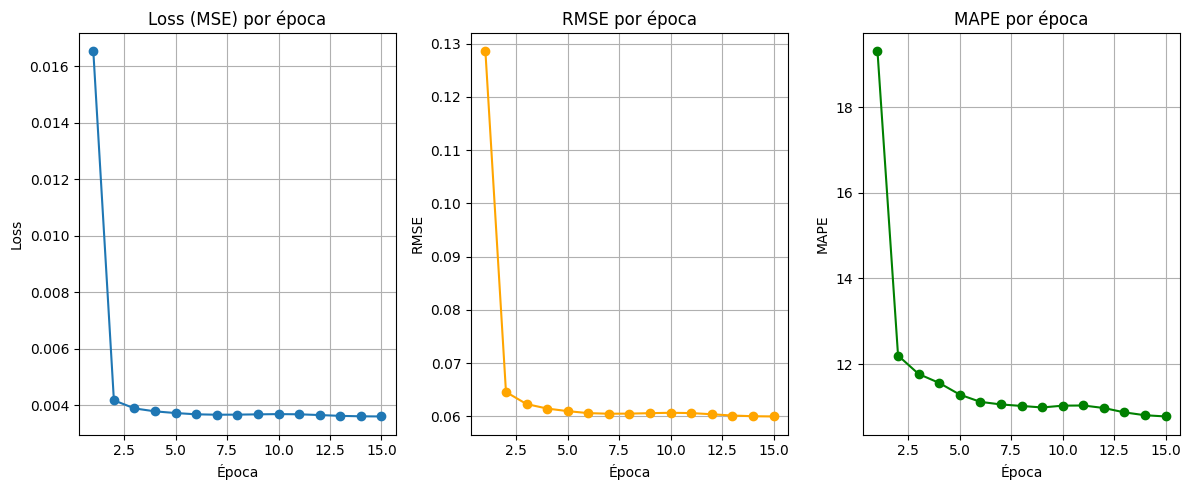

In [13]:
import matplotlib.pyplot as plt

# Extraer métricas del historial
loss = history1.history['loss']
rmse = history1.history['root_mean_squared_error']
mape = history1.history['mean_absolute_percentage_error']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs, loss, marker='o')
plt.title('Loss (MSE) por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(epochs, rmse, marker='o', color='orange')
plt.title('RMSE por época')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(epochs, mape, marker='o', color='green')
plt.title('MAPE por época')
plt.xlabel('Época')
plt.ylabel('MAPE')
plt.grid(True)

plt.tight_layout()
plt.show()

In [12]:
# Obtener las métricas del modelo en el conjunto de entrenamiento
loss, rmse, mape = model1.evaluate(X, y, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 777ms/step - loss: 0.0036 - mean_absolute_percentage_error: 11.1038 - root_mean_squared_error: 0.0602
Pérdida (MSE): 0.0036
RMSE: 0.0602
MAPE: 11.1038


Visualización de imagenes

24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 766ms/step


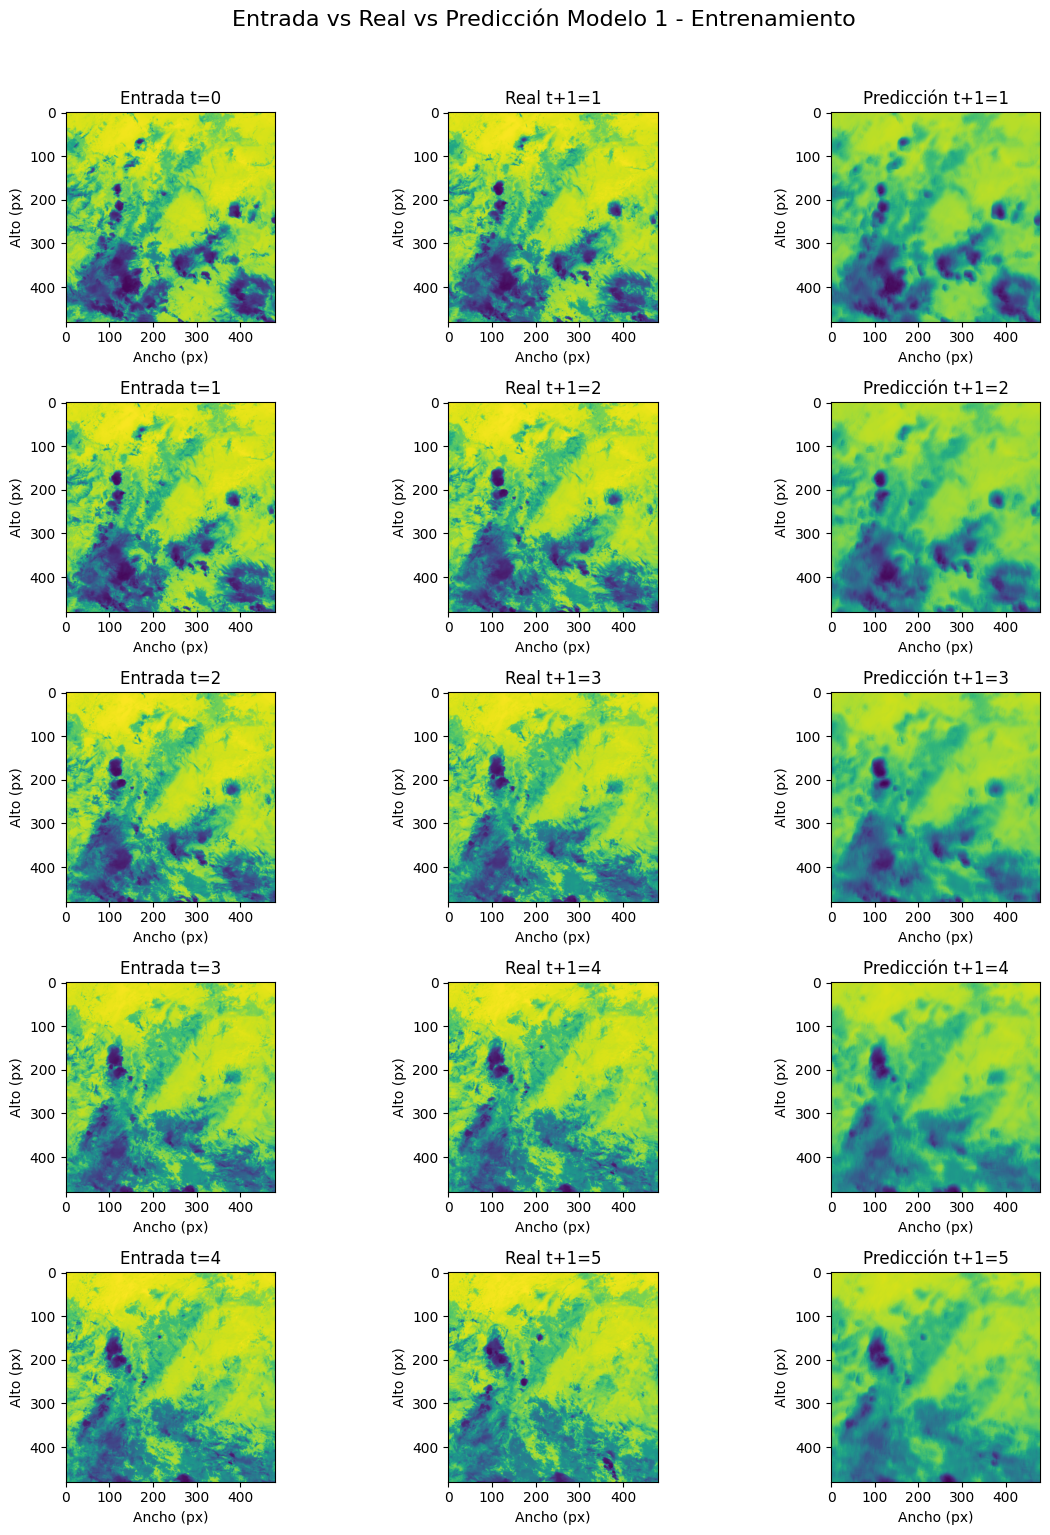

In [14]:
y_pred1 = model1.predict(X)  # Genera las predicciones
mostrar_resultados(
    X, y, y_pred1, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 1 - Entrenamiento",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

Validación

In [19]:
# Directorio original y reducido
d_feb_1s = '/home/smoke/bandas/banda13/feb_01_07_1s'
d_feb_1s_red = '/home/smoke/bandas/banda13/feb_01_07_1s_red'


# Se llama a la función para redimensionar imágenes
resize_npy_images(d_feb_1s, d_feb_1s_red, new_size=(480, 480))  # Llama la función para redimensionar imágenes a 480x480

# Cargar imágenes
file_list = sorted([f for f in os.listdir(d_feb_1s_red) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
#file_list = file_list[:23]  # Selecciona solo los primeros 23 archivos
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images_val = [np.load(os.path.join(d_feb_1s_red, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización
all_pixels = np.concatenate([img.flatten() for img in images_val])
global_min, global_max = np.min(all_pixels), np.max(all_pixels)

images_val = [(img - global_min) / (global_max - global_min + 1e-8) for img in images_val]
images_val = [np.clip(img, 0, 1) for img in images_val]

X_val = np.array(images_val[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y_val = np.array(images_val[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X_val.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y_val.shape}")  # Imprime la forma del array de salida

Procesando 167 imágenes
Forma de X: (166, 480, 480, 1)
Forma de y: (166, 480, 480, 1)


Metricas de validación

In [20]:
# Obtener las métricas del modelo en el conjunto de validación
loss, rmse, mape = model1.evaluate(X_val, y_val, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 729ms/step - loss: 0.0095 - mean_absolute_percentage_error: 27.5624 - root_mean_squared_error: 0.0975
Pérdida (MSE): 0.0095
RMSE: 0.0975
MAPE: 27.5624


Visualización de imagenes con conjunto de validación

6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 628ms/step


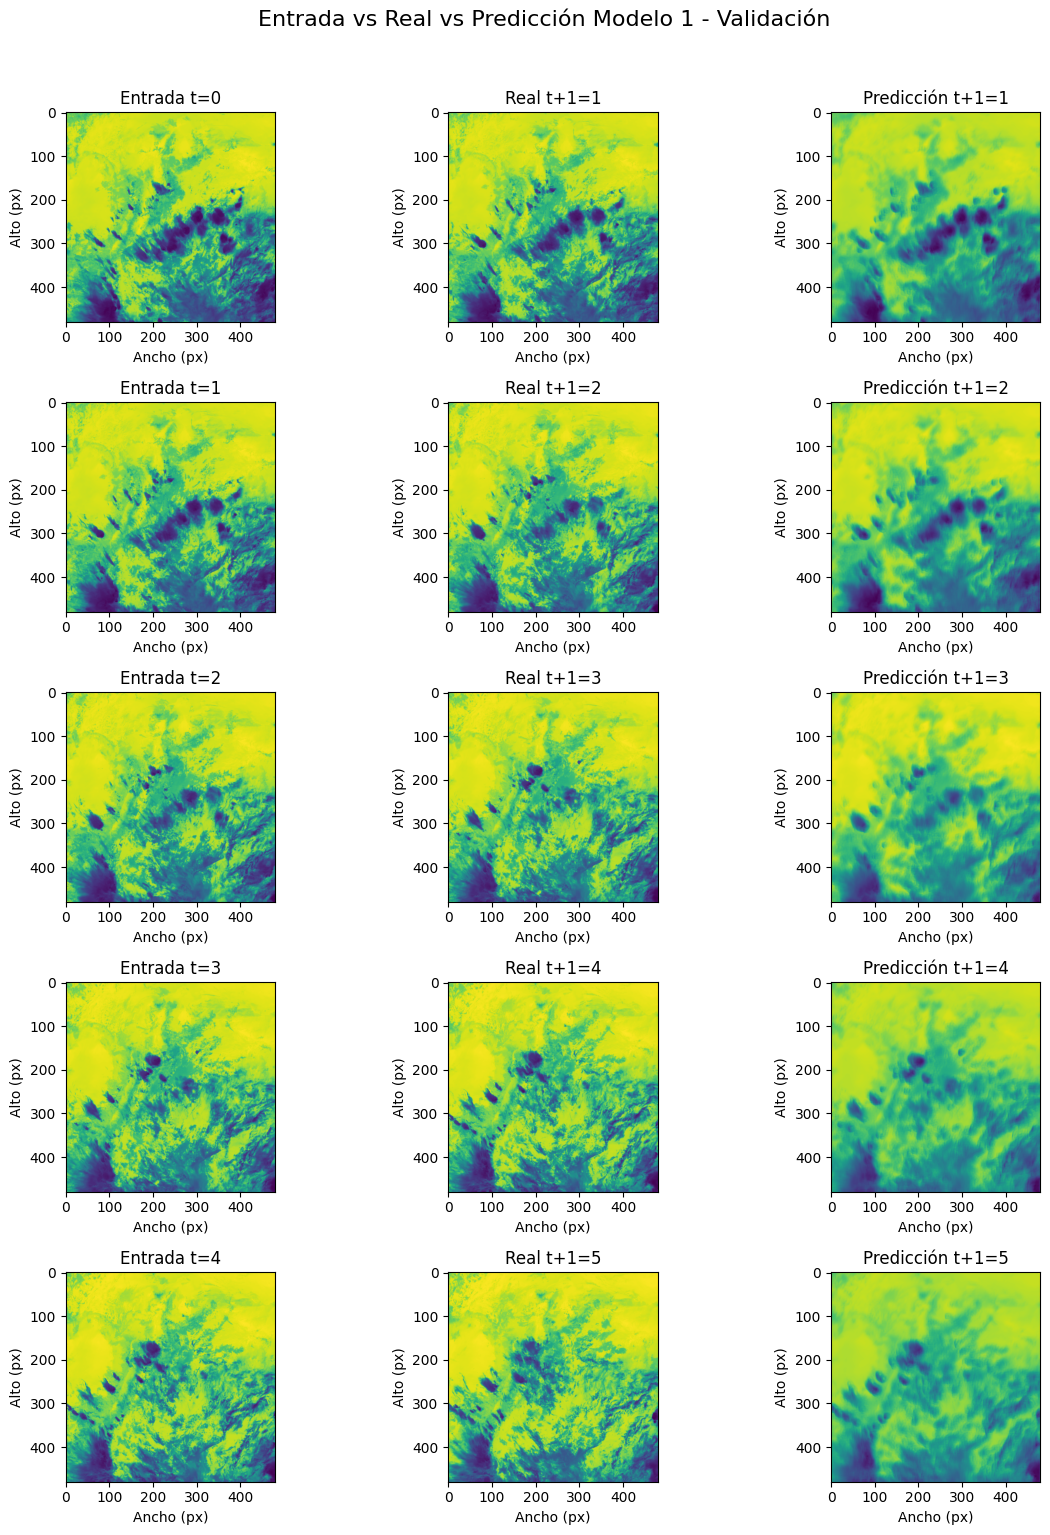

In [22]:
y_pred1_val = model1.predict(X_val)  # Genera las predicciones
mostrar_resultados(
    X_val, y_val, y_pred1_val, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 1 - Validación",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)